# Working with Vector Data from OpenStreetMap

In this notebook, we'll explore how to download and work with multiple layers of vector data from OpenStreetMap (OSM). We will focus on the area around Oxford, Ohio, and save the data as GeoJSON files, which is consistent with our approach to handling geospatial data in Python.

## Key Objectives:
- **Download Vector Data**: Retrieve multiple layers of vector data (e.g., roads, buildings) from OSM.
- **Save as GeoJSON**: Save these layers in the GeoJSON format for further analysis or visualization.

This approach mirrors the workflow described in the original material, but uses modern Python libraries like `osmnx` and `geopandas`.


## Step 1: Install Required Libraries

First, we need to install the necessary Python libraries. We'll be using `osmnx` to download data from OpenStreetMap and `geopandas` to handle geospatial data.

In [1]:
%pip install osmnx geopandas

Note: you may need to restart the kernel to use updated packages.


## Step 2: Retrieve OSM Data for Oxford, Ohio

We will start by retrieving the road network data for Oxford, Ohio, using `osmnx`.


In [2]:
import osmnx as ox

# Define the location (Oxford, Ohio)
place_name = "Oxford, Ohio, USA"

# Download road network data for Oxford
G_roads = ox.graph_from_place(place_name, network_type='drive')

# Convert the graph to a GeoDataFrame
gdf_nodes, gdf_edges = ox.graph_to_gdfs(G_roads)

print("OSM data for Oxford, Ohio has been retrieved.")

OSM data for Oxford, Ohio has been retrieved.


## Step 3: Inspect and Visualize the OSM Data

Next, we'll inspect the data to understand its structure and identify any fields that may need to be reformatted before saving. We'll also visualize the data to get a sense of what we've retrieved.


In [3]:
# Inspect the first few rows of the GeoDataFrame
print("GeoDataFrame structure:")
print(gdf_edges.info())

# Display the first few rows to inspect the data
gdf_edges.head()


GeoDataFrame structure:
<class 'geopandas.geodataframe.GeoDataFrame'>
MultiIndex: 1174 entries, (np.int64(196544968), np.int64(196544969), np.int64(0)) to (np.int64(11336448689), np.int64(1939436356), np.int64(0))
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   osmid     1174 non-null   object  
 1   highway   1174 non-null   object  
 2   name      1169 non-null   object  
 3   oneway    1174 non-null   bool    
 4   reversed  1174 non-null   object  
 5   length    1174 non-null   float64 
 6   geometry  1174 non-null   geometry
 7   lanes     295 non-null    object  
 8   access    28 non-null     object  
 9   maxspeed  197 non-null    object  
 10  ref       149 non-null    object  
 11  bridge    20 non-null     object  
 12  junction  2 non-null      object  
dtypes: bool(1), float64(1), geometry(1), object(10)
memory usage: 156.7+ KB
None


osmid      highway  \
u         v          key                                       
196544968 196544969  0                 18978675  residential   
          196565136  0     [18981050, 18978675]  residential   
          196580452  0                 18984562  residential   
196544969 1939452535 0    [183546056, 18978675]  residential   
          196544968  0                 18978675  residential   

                                                             name  oneway  \
u         v          key                                                    
196544968 196544969  0                           Homestead Avenue   False   
          196565136  0    [Homestead Avenue, North Poplar Street]   False   
          196580452  0                        North Campus Avenue   False   
196544969 1939452535 0            [Homestead Avenue, Bouden Lane]   False   
          196544968  0                           Homestead Avenue   False   

                         reversed      length  \
u         v          key                        
196544968 196544969  0      False  136.610083   
          196565136  0       True  243.452072   
          196580452  0      False  109.251188   
196544969 1939452535 0      False  163.836835   
          196544968  0       True  136.610083   

                                                                   geometry  \
u         v          key                                                      
196544968 196544969  0    LINESTRING (-84.7391 39.51607, -84.73902 39.51...   
          196565136  0    LINESTRING (-84.7391 39.51607, -84.73917 39.51...   
          196580452  0    LINESTRING (-84.7391 39.51607, -84.7391 39.516...   
196544969 1939452535 0    LINESTRING (-84.73751 39.51604, -84.73694 39.5...   
          196544968  0    LINESTRING (-84.73751 39.51604, -84.7376 39.51...   

                         lanes access maxspeed  ref bridge junction  
u         v          key                                             
196544968 196544969  0     NaN    NaN      NaN  NaN    NaN      NaN  
          196565136  0     NaN    NaN      NaN  NaN    NaN      NaN  
          196580452  0     NaN    NaN      NaN  NaN    NaN      NaN  
196544969 1939452535 0     NaN    NaN      NaN  NaN    NaN      NaN  
          196544968  0     NaN    NaN      NaN  NaN    NaN      NaN

### Visualizing the Road Network

Let's visualize the road network to see what the data looks like on a map.


<Axes: >

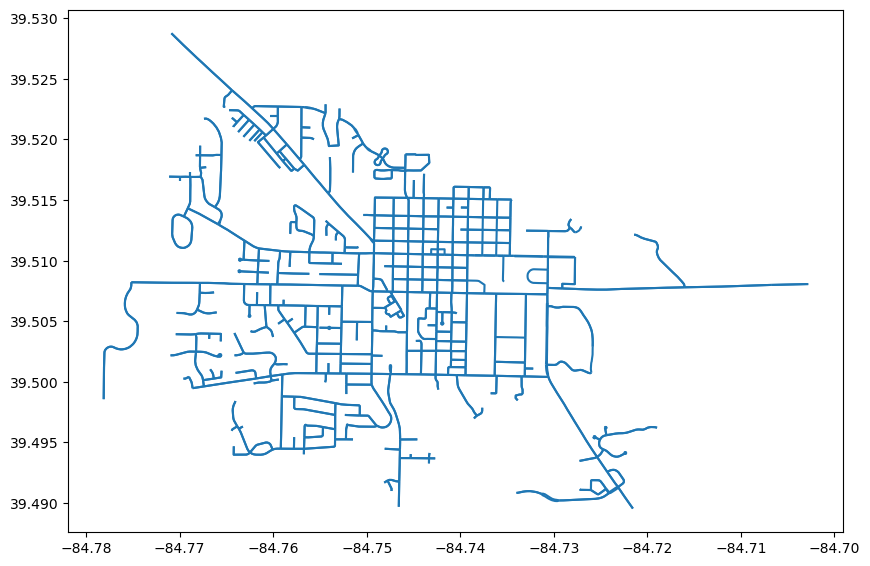

In [4]:
# Plot the road network
gdf_edges.plot(figsize=(10, 10))

## Step 4: Reformat Offending Fields and Save as GeoJSON

Now that we've inspected the data, we can reformat any fields that may cause issues (e.g., fields containing lists) to strings, ensuring that the data can be saved properly as a GeoJSON file.


In [5]:
gdf_edges.iloc[100]

osmid                                   [18980128, 554857298]
highway                                             secondary
name                                     West Chestnut Street
oneway                                                  False
reversed                                        [False, True]
length                                              230.29765
geometry    LINESTRING (-84.7521773 39.5006786, -84.750018...
lanes                                                       3
access                                                    NaN
maxspeed                                                  NaN
ref                                                    SR 732
bridge                                                    NaN
junction                                                  NaN
Name: (196556858, 196556859, 0), dtype: object

In [6]:
import os

# Reformat fields that contain lists or non-GeoJSON-friendly types
for column in gdf_edges.columns:
    if column != gdf_edges.geometry.name:  # Skip the geometry column
        if gdf_edges[column].apply(lambda x: isinstance(x, list)).any():
            gdf_edges[column] = gdf_edges[column].apply(lambda x: str(x) if isinstance(x, list) else x)

# Create a directory to store the GeoJSON files
os.makedirs("data", exist_ok=True)

# Save the edges (which represent roads) to a GeoJSON file
geojson_path_roads = "data/oxford_roads.geojson"
gdf_edges.to_file(geojson_path_roads, driver="GeoJSON")

print(f"Roads data saved to: {geojson_path_roads}")


Roads data saved to: data/oxford_roads.geojson


## Step 5: Downloading and Saving Additional Layers

In this step, we'll download additional vector data layers from OSM, such as buildings and parks, for Oxford, Ohio. We'll inspect and reformat the data if necessary, and then save each layer as a separate GeoJSON file.

### Layers to Download:
1. **Buildings**
2. **Parks**

We'll use the same approach as we did for the road network, ensuring that each layer is saved in a GeoJSON format that is easy to work with for further analysis.



### Download and Save Buildings Layer

Let's start by downloading the buildings data for Oxford, Ohio, and saving it as a GeoJSON file.



Buildings GeoDataFrame structure:
<class 'geopandas.geodataframe.GeoDataFrame'>
MultiIndex: 4307 entries, ('relation', np.int64(2443713)) to ('way', np.int64(1355290772))
Columns: 115 entries, geometry to is_in:state_code
dtypes: geometry(1), object(114)
memory usage: 4.0+ MB
None


<Axes: >

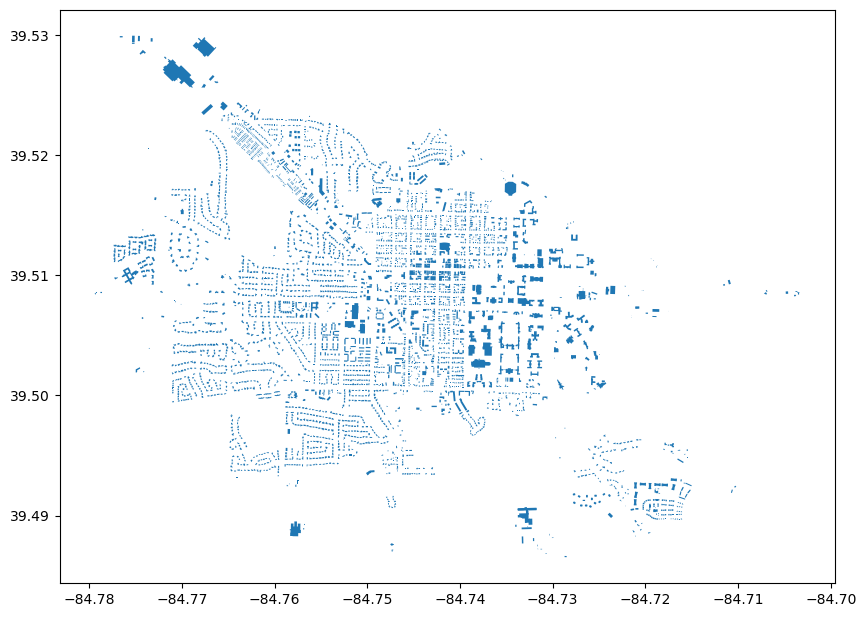

In [7]:
# Download buildings data for Oxford
gdf_buildings = ox.features_from_place(place_name, tags={'building': True})

# Inspect the structure of the buildings data
print()
print("Buildings GeoDataFrame structure:")
print(gdf_buildings.info())

# Display the first few rows to inspect the data
gdf_buildings.head()

# Plot the buildings
gdf_buildings.plot(figsize=(10, 10))

### Reformat and Save Buildings Layer

We'll now reformat any fields that may cause issues and save the buildings layer as a GeoJSON file.


In [8]:
# Reformat fields that contain lists or non-GeoJSON-friendly types
for column in gdf_buildings.columns:
    if column != gdf_buildings.geometry.name:  # Skip the geometry column
        if gdf_buildings[column].apply(lambda x: isinstance(x, list)).any():
            gdf_buildings[column] = gdf_buildings[column].apply(lambda x: str(x) if isinstance(x, list) else x)

# Save the buildings data to a GeoJSON file
geojson_path_buildings = "data/oxford_buildings.geojson"
gdf_buildings.to_file(geojson_path_buildings, driver="GeoJSON")

print(f"Buildings data saved to: {geojson_path_buildings}")


Buildings data saved to: data/oxford_buildings.geojson


### Download and Save Parks Layer

Next, we'll download the parks data for Oxford, Ohio, and save it as a GeoJSON file.

Parks GeoDataFrame structure:
<class 'geopandas.geodataframe.GeoDataFrame'>
MultiIndex: 15 entries, ('way', np.int64(107937748)) to ('way', np.int64(1039193666))
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   geometry                 15 non-null     geometry
 1   disused:amenity          1 non-null      object  
 2   ele                      8 non-null      object  
 3   gnis:feature_id          8 non-null      object  
 4   leisure                  15 non-null     object  
 5   name                     12 non-null     object  
 6   old_name                 2 non-null      object  
 7   operator                 3 non-null      object  
 8   access                   1 non-null      object  
 9   alt_name                 1 non-null      object  
 10  wikidata                 6 non-null      object  
 11  name:etymology:wikidata  1 non-null      object  
 12  fixme                    1 non

<Axes: >

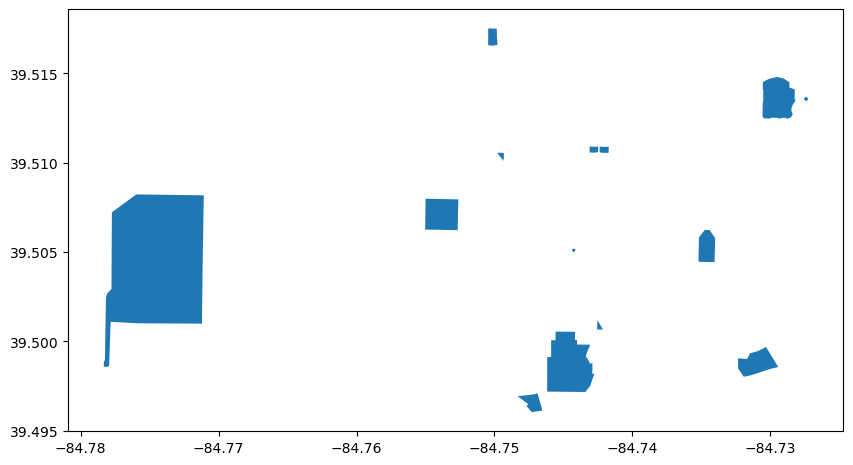

In [9]:
# Download parks data for Oxford
gdf_parks = ox.features_from_place(place_name, tags={'leisure': 'park'})

# Inspect the structure of the parks data
print("Parks GeoDataFrame structure:")
print(gdf_parks.info())

# Display the first few rows to inspect the data
gdf_parks.head()

# Plot the parks
gdf_parks.plot(figsize=(10, 10))

### Reformat and Save Parks Layer

We'll now reformat any fields that may cause issues and save the parks layer as a GeoJSON file.


In [10]:
# Reformat fields that contain lists or non-GeoJSON-friendly types
for column in gdf_parks.columns:
    if column != gdf_parks.geometry.name:  # Skip the geometry column
        if gdf_parks[column].apply(lambda x: isinstance(x, list)).any():
            gdf_parks[column] = gdf_parks[column].apply(lambda x: str(x) if isinstance(x, list) else x)

# Save the parks data to a GeoJSON file
geojson_path_parks = "data/oxford_parks.geojson"
gdf_parks.to_file(geojson_path_parks, driver="GeoJSON")

print(f"Parks data saved to: {geojson_path_parks}")


Parks data saved to: data/oxford_parks.geojson


## Understanding Data Sources, Layers, Features, and Geometry

The figure below illustrates the structure of geospatial data:

- **Data Source**: The entire dataset, which in our case is represented by the folder containing all the GeoJSON files.
- **Layer**: Each GeoJSON file represents a different layer (e.g., roads, buildings).
- **Feature**: An individual item in a layer (e.g., a single building or road).
- **Geometry**: The spatial shape of the feature (e.g., point, line, polygon).
- **Attributes**: Additional information about the feature (e.g., name, area, elevation).

Let's see how this applies to the OSM data we've been working with in this notebook.


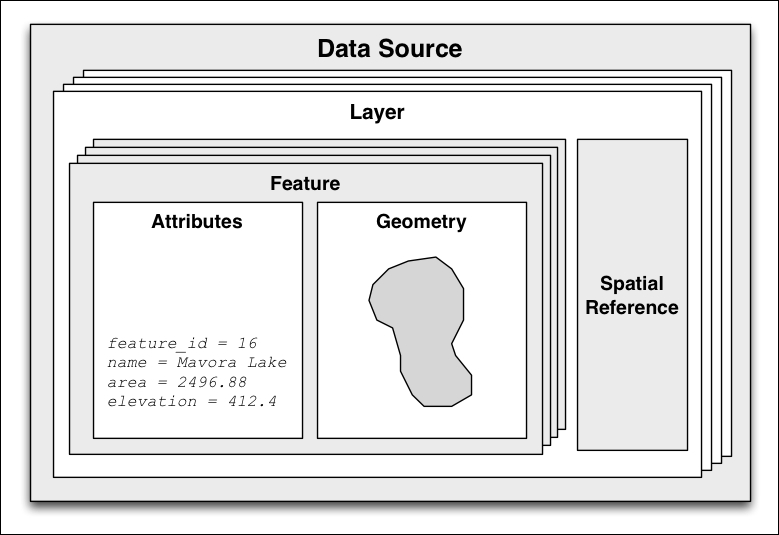

### Applying the Concept with OSM Data

We'll use the building data for Oxford, Ohio, as an example. Here's how the data we've downloaded fits into the structure illustrated in the figure:


In [11]:
benton_hall = gdf_buildings[gdf_buildings.name.str.contains('Benton', case=False, na=False)]

In [12]:
benton_hall

,,geometry,building,ele,gnis:feature_id,leisure,name,name_1,name_2,operator,source,...,start_date,addr:unit,level,outdoor_seating,female:signed,male:signed,club,playground,type,is_in:state_code
element,id,,,,,,,,,,,,,,,,,,,,,
way,397382395,"POLYGON ((-84.73406 39.51068, -84.73406 39.510...",university,NaN,NaN,NaN,Benton Hall,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
import geopandas as gpd

# Example: Data Source
# In our case, the data source is the folder containing all GeoJSON files
data_source_folder = "data/"

# Load the buildings GeoJSON file as an example layer
gdf_buildings = gpd.read_file(f"{data_source_folder}/oxford_buildings.geojson")

# Example: Layer
# The layer is the collection of all buildings
layer = gdf_buildings

# Example: Feature
# A single feature might be one building
feature = layer.iloc[0]  # First feature in the layer

# Example: Geometry and Attributes
geometry = feature.geometry
attributes = feature.dropna().drop("geometry")  # Drop NaN values and the geometry column

# Display the feature's geometry and attributes
print("Geometry of the feature (building):")
print(geometry)
print("\nAttributes of the feature (building):")
print(attributes)


Geometry of the feature (building):
POLYGON ((-84.7560645 39.5077539, -84.7555389 39.507749, -84.7555384 39.5077845, -84.7555381 39.5078016, -84.7553389 39.5077998, -84.7553391 39.5077855, -84.7552875 39.507785, -84.7552883 39.5077337, -84.7552675 39.5077335, -84.7552694 39.5076112, -84.7552918 39.5076114, -84.7552925 39.5075632, -84.7553476 39.5075637, -84.7553687 39.5075639, -84.7553717 39.5073757, -84.7553596 39.5073757, -84.7553399 39.5073757, -84.7553097 39.5073663, -84.7552871 39.5073515, -84.7552782 39.507334, -84.7552787 39.5073001, -84.7552795 39.507243, -84.7554333 39.5072444, -84.7554351 39.507129, -84.7555863 39.5071304, -84.7555845 39.5072445, -84.7559047 39.5072475, -84.7559049 39.5072357, -84.755909 39.5069766, -84.7559993 39.5069774, -84.7560818 39.5069782, -84.7560696 39.5077539, -84.7560645 39.5077539), (-84.7558939 39.5074091, -84.7559269 39.5074094, -84.7559273 39.5073831, -84.755868 39.5073825, -84.7555756 39.5073799, -84.7555558 39.5073798, -84.755552 39.5076286, 

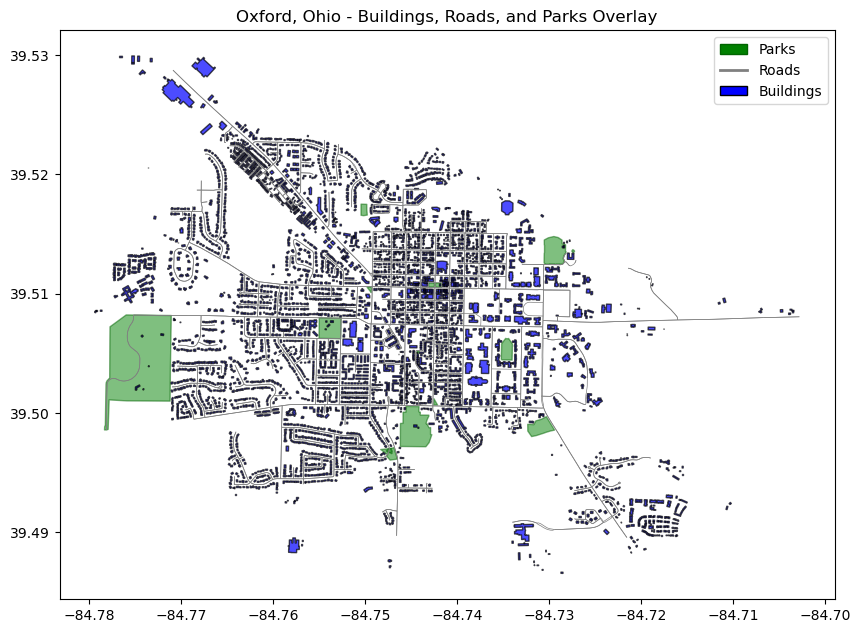

In [14]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Create a plot with multiple layers
fig, ax = plt.subplots(figsize=(10, 10))

# Plot parks first
gdf_parks.plot(ax=ax, color='green', alpha=0.5, edgecolor='darkgreen', label='Parks')

# Plot roads on top of parks
gdf_edges.plot(ax=ax, color='gray', linewidth=0.5, label='Roads')

# Plot buildings on top of parks and roads
gdf_buildings.plot(ax=ax, color='blue', alpha=0.7, edgecolor='black', label='Buildings')

# Customize plot
ax.set_title("Oxford, Ohio - Buildings, Roads, and Parks Overlay")

# The default plotting method did notpolulate the lgened properly,
# so we customize it here.
legend_elements = [
    Patch(facecolor='green', edgecolor='darkgreen', label='Parks'),
    Line2D([0], [0], color='gray', lw=2, label='Roads'),
    Patch(facecolor='blue', edgecolor='black', label='Buildings')
]

ax.legend(handles=legend_elements, loc='upper right')

plt.show()